# Gold Return Model Comparison

Compares the Lasso, LSTM, and XGBoost models' test-set predictive accuracy side by side.

## 1. Setup and Load Results

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

RESULTS_DIR = Path("results")

### 1.1 Load Metrics

In [2]:
lasso_metrics = pd.read_csv(RESULTS_DIR / "lasso_metrics.csv")
lstm_metrics = pd.read_csv(RESULTS_DIR / "lstm_metrics.csv")
xgboost_metrics = pd.read_csv(RESULTS_DIR / "xgboost_metrics.csv")

lasso_metrics["Model_Family"] = "Lasso"
lstm_metrics["Model_Family"] = "LSTM"
xgboost_metrics["Model_Family"] = "XGBoost"

# Note: the Lasso notebook's metrics file does not include a Zero-Return Baseline
# row (only Baseline Lasso and Tuned Lasso), while LSTM and XGBoost each include one.
all_metrics = pd.concat(
    [lasso_metrics, lstm_metrics, xgboost_metrics],
    ignore_index=True
)

all_metrics

,Model,MAE,MSE,RMSE,R2,Directional_Accuracy,Model_Family
0,Baseline Lasso,0.009173,0.000174,0.013195,0.000677,0.516600,Lasso
1,Tuned Lasso,0.009163,0.000174,0.013197,0.000323,0.532537,Lasso
2,Zero-Return Baseline,0.009195,0.000175,0.013236,-0.005592,NaN,LSTM
3,Baseline LSTM,0.009158,0.000174,0.013195,0.000614,0.557769,LSTM
4,Tuned LSTM,0.009123,0.000174,0.013183,0.002461,0.564409,LSTM
5,Zero-Return Baseline,0.009195,0.000175,0.013236,-0.005592,NaN,XGBoost
6,Baseline XGBoost,0.009201,0.000174,0.013206,-0.000923,0.541833,XGBoost
7,Tuned XGBoost,0.009191,0.000175,0.013233,-0.005104,0.527224,XGBoost


### 1.2 Load Predictions

In [3]:
lasso_predictions = pd.read_csv(
    RESULTS_DIR / "lasso_predictions.csv",
    parse_dates=["Date"]
)
lstm_predictions = pd.read_csv(
    RESULTS_DIR / "lstm_predictions.csv",
    parse_dates=["Date"]
)
xgboost_predictions = pd.read_csv(
    RESULTS_DIR / "xgboost_predictions.csv",
    parse_dates=["Date"]
)

print("Lasso test rows:", len(lasso_predictions))
print("LSTM test rows:", len(lstm_predictions))
print("XGBoost test rows:", len(xgboost_predictions))

Lasso test rows: 753
LSTM test rows: 753
XGBoost test rows: 753


## 2. Tuned-Model Accuracy Comparison

Each notebook tunes its own model and reports a "Tuned" row. This pulls just those rows out for a direct side-by-side comparison.

In [4]:
tuned_rows = all_metrics[
    all_metrics["Model"].str.contains("Tuned", case=False)
].copy()

tuned_rows = tuned_rows[
    ["Model_Family", "Model", "MAE", "MSE", "RMSE", "R2", "Directional_Accuracy"]
].reset_index(drop=True)

tuned_rows

,Model_Family,Model,MAE,MSE,RMSE,R2,Directional_Accuracy
0,Lasso,Tuned Lasso,0.009163,0.000174,0.013197,0.000323,0.532537
1,LSTM,Tuned LSTM,0.009123,0.000174,0.013183,0.002461,0.564409
2,XGBoost,Tuned XGBoost,0.009191,0.000175,0.013233,-0.005104,0.527224


### 2.1 RMSE and MAE Comparison

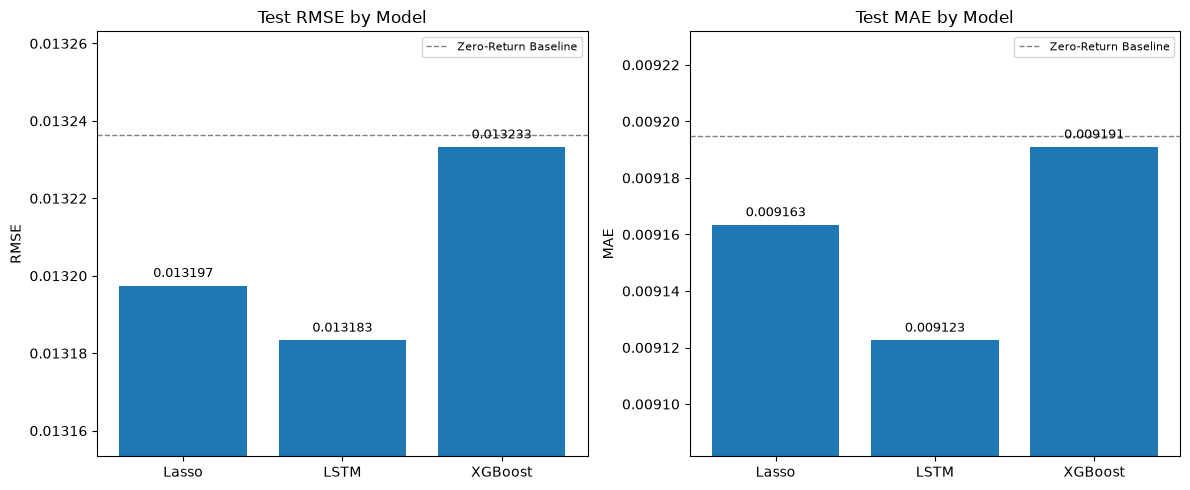

In [5]:
zero_return_row = all_metrics[
    all_metrics["Model"] == "Zero-Return Baseline"
].iloc[0]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, metric in zip(axes, ["RMSE", "MAE"]):
    values = tuned_rows[metric]
    value_range = values.max() - values.min()
    padding = value_range * 0.6 if value_range > 0 else values.min() * 0.01

    bars = ax.bar(tuned_rows["Model_Family"], values)

    for bar, value in zip(bars, values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            value + padding * 0.05,
            f"{value:.6f}",
            ha="center",
            va="bottom",
            fontsize=9
        )

    ax.axhline(
        y=zero_return_row[metric],
        linestyle="--",
        color="gray",
        linewidth=1,
        label="Zero-Return Baseline"
    )

    ax.set_ylim(values.min() - padding, values.max() + padding)
    ax.set_title(f"Test {metric} by Model")
    ax.set_ylabel(metric)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

### 2.2 R² Comparison

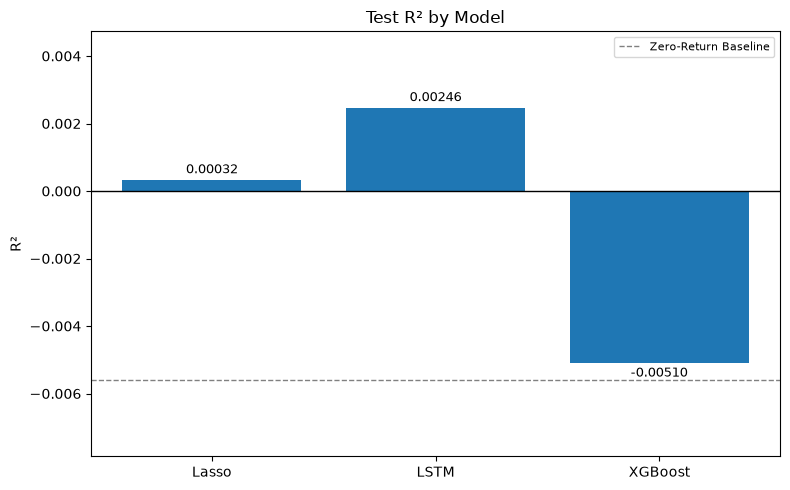

In [6]:
values = tuned_rows["R2"]
value_range = values.max() - values.min()
padding = value_range * 0.3 if value_range > 0 else 0.001

plt.figure(figsize=(8, 5))

bars = plt.bar(tuned_rows["Model_Family"], values)

for bar, value in zip(bars, values):
    offset = padding * 0.05 if value >= 0 else -padding * 0.05
    va = "bottom" if value >= 0 else "top"
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + offset,
        f"{value:.5f}",
        ha="center",
        va=va,
        fontsize=9
    )

plt.axhline(y=0, linestyle="-", color="black", linewidth=1)
plt.axhline(
    y=zero_return_row["R2"],
    linestyle="--",
    color="gray",
    linewidth=1,
    label="Zero-Return Baseline"
)

plt.ylim(
    min(values.min(), zero_return_row["R2"]) - padding,
    max(values.max(), 0) + padding
)
plt.ylabel("R²")
plt.title("Test R² by Model")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

### 2.3 Directional Accuracy Comparison

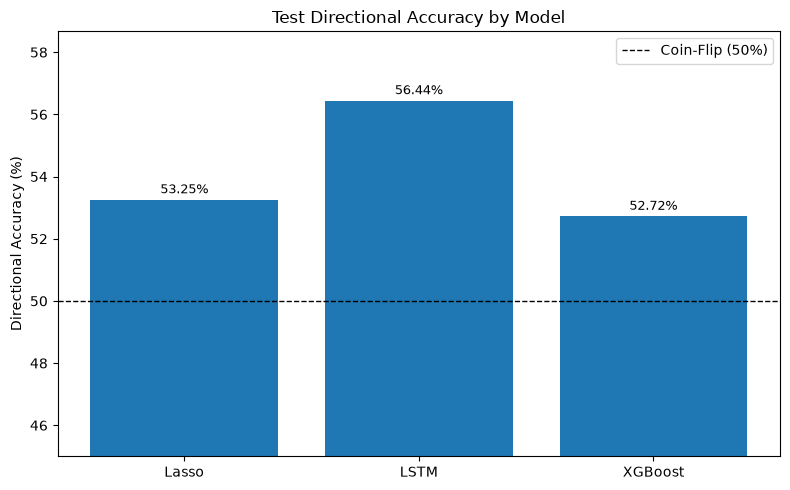

In [7]:
values = tuned_rows["Directional_Accuracy"] * 100
value_range = values.max() - values.min()
padding = max(value_range * 0.6, 2)

plt.figure(figsize=(8, 5))

bars = plt.bar(tuned_rows["Model_Family"], values)

for bar, value in zip(bars, values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + padding * 0.05,
        f"{value:.2f}%",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.axhline(y=50, linestyle="--", color="black", linewidth=1, label="Coin-Flip (50%)")

plt.ylim(min(45, values.min() - padding), values.max() + padding)
plt.ylabel("Directional Accuracy (%)")
plt.title("Test Directional Accuracy by Model")
plt.legend()
plt.tight_layout()
plt.show()

## 3. Actual vs. Predicted Overlay

Merges each model's tuned predictions onto a common date index so all three can be plotted against the same actual returns. Note that each notebook's test window may differ slightly if the underlying data differs in length; this merge keeps only dates present in all three prediction files.

In [8]:
comparison = lasso_predictions[["Date", "Actual_Return", "Tuned_Lasso_Prediction"]].merge(
    lstm_predictions[["Date", "Tuned_LSTM_Prediction"]],
    on="Date",
    how="inner"
).merge(
    xgboost_predictions[["Date", "Tuned_XGBoost_Prediction"]],
    on="Date",
    how="inner"
)

print("Common test rows across all three models:", len(comparison))
comparison.head()

Common test rows across all three models: 753


,Date,Actual_Return,Tuned_Lasso_Prediction,Tuned_LSTM_Prediction,Tuned_XGBoost_Prediction
0,2023-07-11,0.012810,0.000579,0.001750,0.000170
1,2023-07-12,0.001532,0.003813,0.003431,0.002182
2,2023-07-13,0.000459,0.002278,0.003872,0.001953
3,2023-07-14,-0.003936,-0.001735,0.001722,-0.001306
4,2023-07-17,0.012622,0.000758,0.001954,0.000492


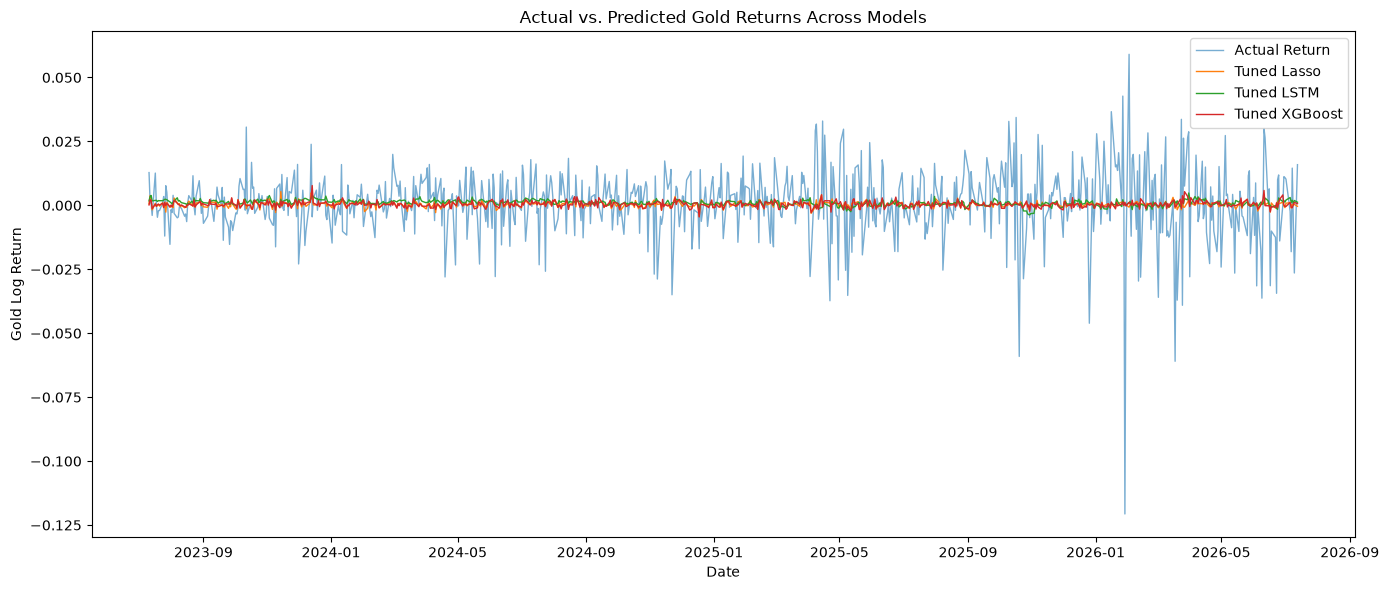

In [9]:
plt.figure(figsize=(14, 6))

plt.plot(comparison["Date"], comparison["Actual_Return"], label="Actual Return", alpha=0.6, linewidth=1)
plt.plot(comparison["Date"], comparison["Tuned_Lasso_Prediction"], label="Tuned Lasso", linewidth=1)
plt.plot(comparison["Date"], comparison["Tuned_LSTM_Prediction"], label="Tuned LSTM", linewidth=1)
plt.plot(comparison["Date"], comparison["Tuned_XGBoost_Prediction"], label="Tuned XGBoost", linewidth=1)

plt.xlabel("Date")
plt.ylabel("Gold Log Return")
plt.title("Actual vs. Predicted Gold Returns Across Models")
plt.legend()
plt.tight_layout()
plt.show()

## 4. Recomputed Accuracy on the Common Date Range

The metrics in Section 2 were each computed on that model's own full test set, which may not be identical across models. This recomputes MAE, RMSE, R², and directional accuracy on only the shared date range from Section 3, so the comparison is apples-to-apples.

In [10]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

recomputed_rows = []

model_columns = {
    "Lasso": "Tuned_Lasso_Prediction",
    "LSTM": "Tuned_LSTM_Prediction",
    "XGBoost": "Tuned_XGBoost_Prediction",
}

for model_family, column in model_columns.items():
    mae = mean_absolute_error(comparison["Actual_Return"], comparison[column])
    mse = mean_squared_error(comparison["Actual_Return"], comparison[column])
    rmse = np.sqrt(mse)
    r2 = r2_score(comparison["Actual_Return"], comparison[column])
    directional_accuracy = np.mean(
        np.sign(comparison[column]) == np.sign(comparison["Actual_Return"])
    )

    recomputed_rows.append({
        "Model_Family": model_family,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R2": r2,
        "Directional_Accuracy": directional_accuracy,
    })

recomputed_metrics = pd.DataFrame(recomputed_rows)
recomputed_metrics

,Model_Family,MAE,MSE,RMSE,R2,Directional_Accuracy
0,Lasso,0.009163,0.000174,0.013197,0.000323,0.532537
1,LSTM,0.009123,0.000174,0.013183,0.002461,0.564409
2,XGBoost,0.009191,0.000175,0.013233,-0.005104,0.527224


## 5. Conclusion

On the shared 753-day test range (Section 4), the tuned models rank as follows:

| Model | MAE | RMSE | R² | Directional Accuracy |
|---|---|---|---|---|
| LSTM | 0.009123 | 0.013183 | 0.002461 | 56.44% |
| Lasso | 0.009163 | 0.013197 | 0.000323 | 53.25% |
| XGBoost | 0.009191 | 0.013233 | -0.005104 | 52.72% |

LSTM is the best-performing model on every metric — lowest MAE and RMSE, the only positive R², and the highest directional accuracy. XGBoost is the weakest, with a slightly negative R² (worse than predicting zero every day). Lasso sits in between.

That said, the gap between models is small relative to the gap between any of them and a meaningful predictive signal. The zero-return baseline (predicting no change every day) achieves an RMSE of about 0.013236 and an R² of about -0.0056 on this same data — LSTM's RMSE (0.013183) is only marginally better, and its R² (0.0025) still explains almost none of the variance in next-day returns. Directional accuracy for all three models is modestly above a 50% coin flip, with LSTM's 56.4% being the most notable, but none of the three model families demonstrates a strong, reliable predictive edge on this dataset.

Overall: **LSTM is the recommended model of the three**, but the honest conclusion is that all three approaches struggle to meaningfully outperform a naive baseline at predicting the magnitude of next-day gold returns, and only weakly outperform chance at predicting direction.